# Follower Behaviour Analysis
Data-driven justification for the three leader strategies used in `comp34612_project.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_PATH = 'comp34612/data.xlsx'

mk1 = pd.read_excel(DATA_PATH, sheet_name='Follower_Mk1')
mk2 = pd.read_excel(DATA_PATH, sheet_name='Follower_Mk2')
mk3 = pd.read_excel(DATA_PATH, sheet_name='Follower_Mk3')

followers = {'MK1': mk1, 'MK2': mk2, 'MK3': mk3}
colors    = {'MK1': '#2196F3', 'MK2': '#F44336', 'MK3': '#4CAF50'}

print("Loaded. Shape:", mk1.shape)
mk1.head(3)

Loaded. Shape: (100, 4)


,Date,Leader's Price,Follower's Price,Cost
0,1,1.721828,3.513812,1
1,2,1.779242,3.365436,1
2,3,1.787140,3.732502,1


## 1 — Follower price time series
Are follower prices stable, trending, or do they shift regime over time?

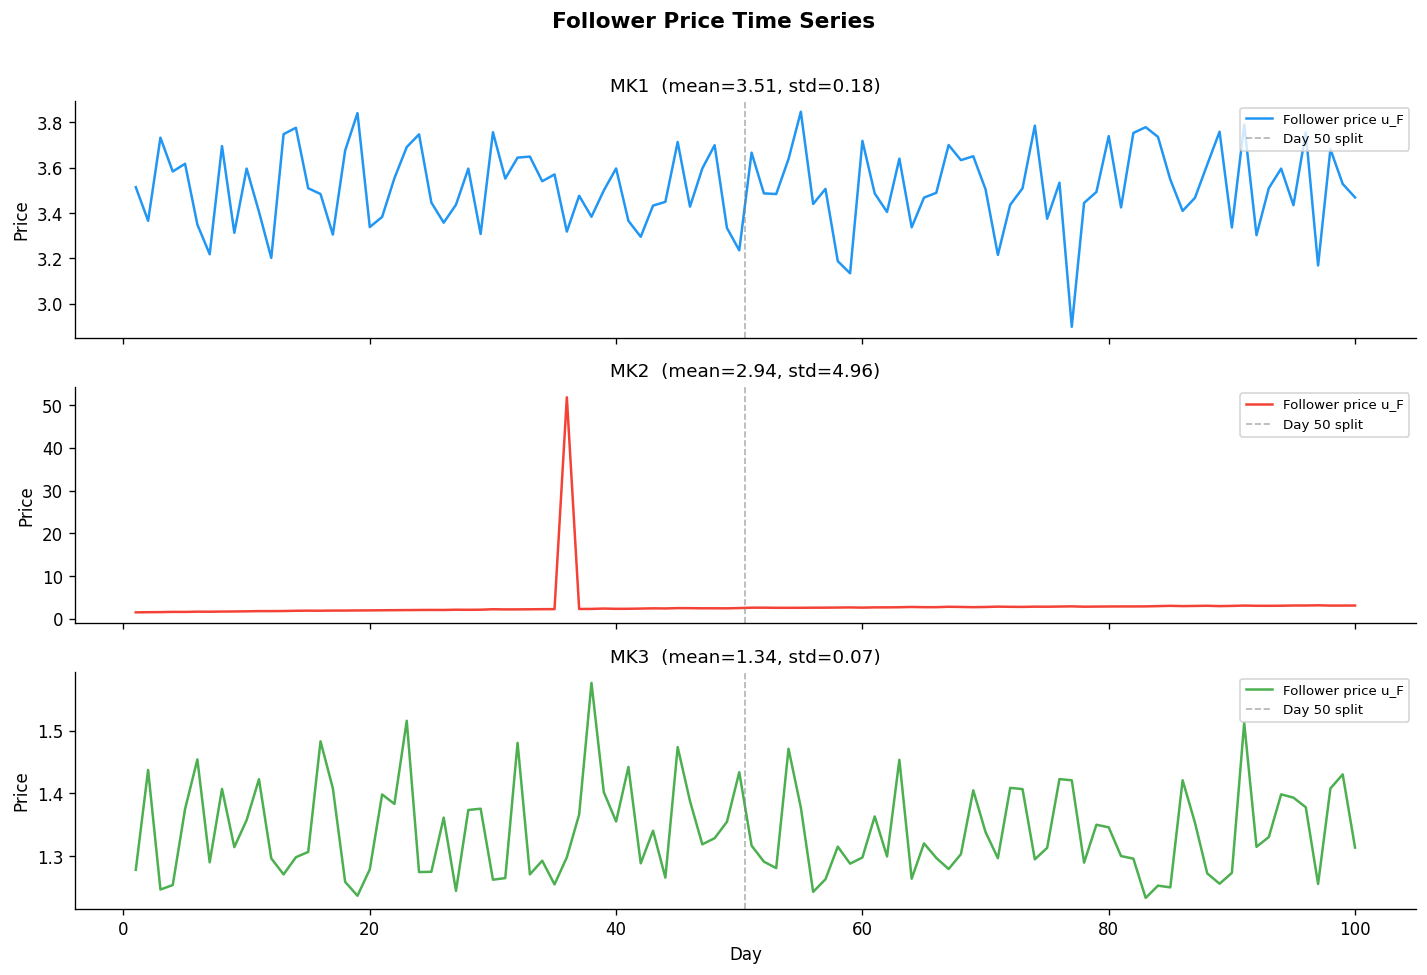

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, (name, df) in zip(axes, followers.items()):
    ul = df["Leader's Price"]
    uf = df["Follower's Price"]
    days = df['Date']
    ax.plot(days, uf, color=colors[name], lw=1.5, label="Follower price u_F")
    ax.axvline(50.5, color='grey', lw=1, ls='--', alpha=0.6, label='Day 50 split')
    ax.set_ylabel("Price", fontsize=10)
    ax.set_title(f'{name}  (mean={uf.mean():.2f}, std={uf.std():.2f})', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel("Day", fontsize=10)
fig.suptitle("Follower Price Time Series", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2 — Leader vs Follower price scatter
Does the follower price respond linearly to the leader price?  
We fit `u_F = a·u_L + b` for each follower.

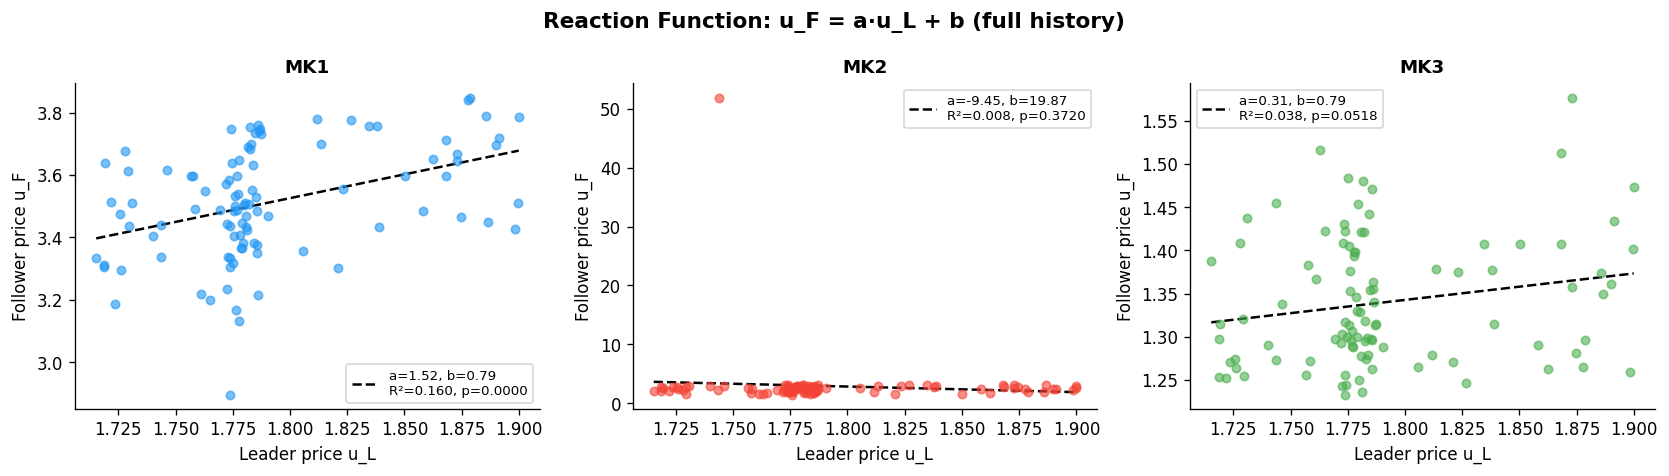

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, df) in zip(axes, followers.items()):
    ul = df["Leader's Price"].values
    uf = df["Follower's Price"].values
    slope, intercept, r, p, _ = stats.linregress(ul, uf)
    r2 = r ** 2

    ax.scatter(ul, uf, color=colors[name], alpha=0.6, s=25, zorder=3)
    x_line = np.linspace(ul.min(), ul.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, 'k--', lw=1.5,
            label=f'a={slope:.2f}, b={intercept:.2f}\nR²={r2:.3f}, p={p:.4f}')
    ax.set_xlabel("Leader price u_L", fontsize=10)
    ax.set_ylabel("Follower price u_F", fontsize=10)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle("Reaction Function: u_F = a·u_L + b (full history)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3 — Regime analysis: days 1–50 vs 51–100
Is the follower's reaction function stable over time, or does the slope shift?  
This directly motivates the choice of history window for each leader.

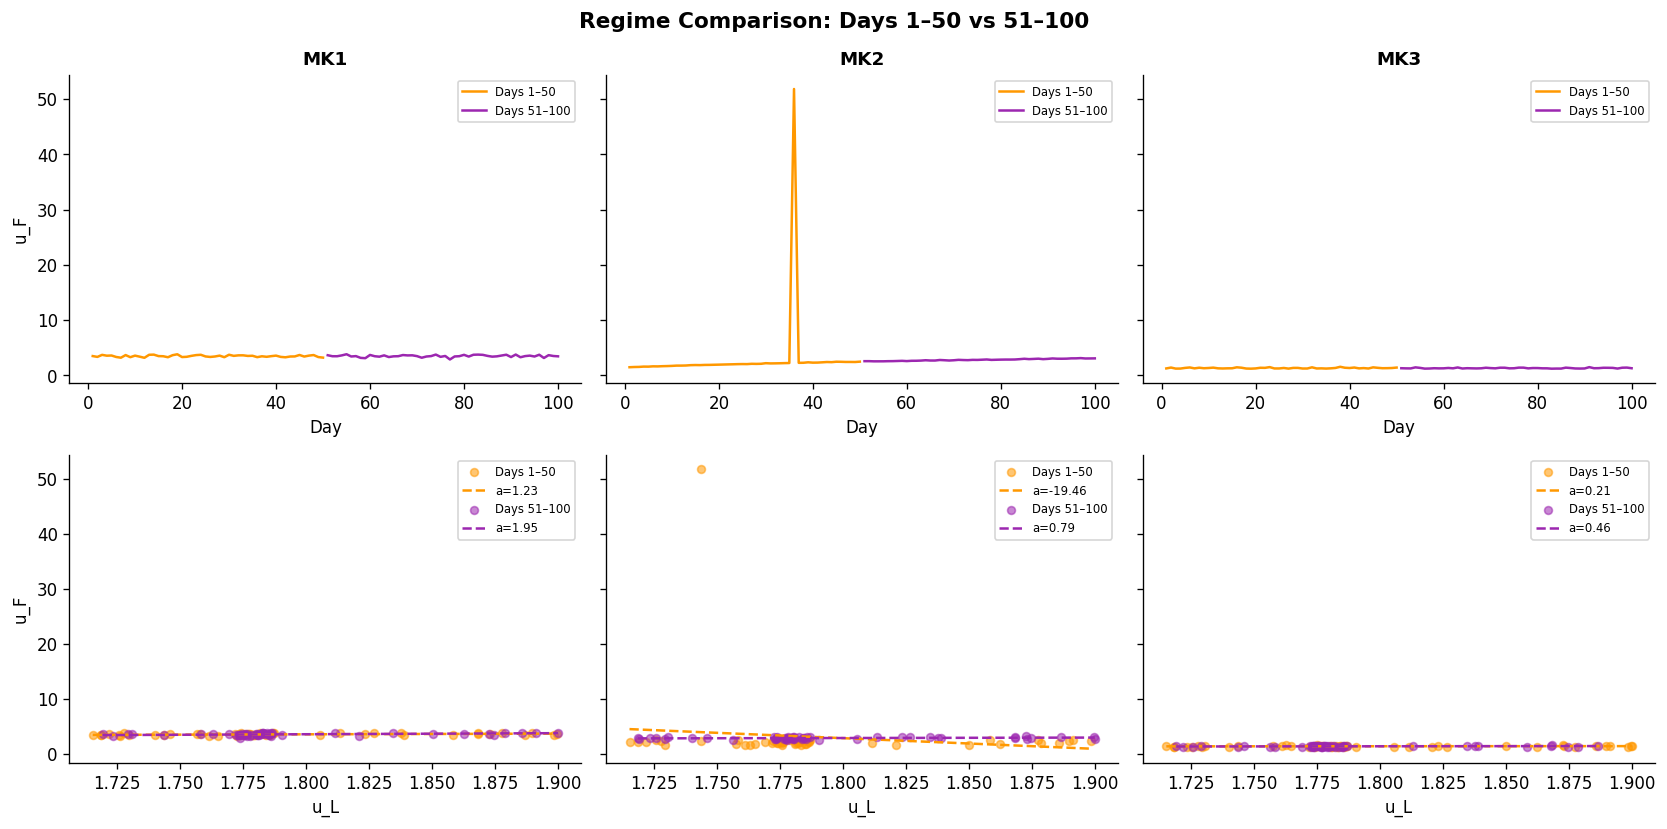

,Follower,Period,Slope (a),Intercept (b),R²,p-value
0,MK1,Days 1–50,1.228,1.308,0.147,0.0060
1,MK1,Days 51–100,1.947,0.029,0.185,0.0018
2,MK2,Days 1–50,-19.462,37.849,0.017,0.3632
3,MK2,Days 51–100,0.794,1.415,0.045,0.1387
4,MK3,Days 1–50,0.209,0.972,0.019,0.3378
5,MK3,Days 51–100,0.462,0.507,0.075,0.0538


In [4]:
rows = []
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey='row')

period_colors = {'Days 1–50': '#FF9800', 'Days 51–100': '#9C27B0'}

for col, (name, df) in enumerate(followers.items()):
    ul = df["Leader's Price"].values
    uf = df["Follower's Price"].values

    for period, (lo, hi) in [('Days 1–50', (0, 50)), ('Days 51–100', (50, 100))]:
        ul_p = ul[lo:hi]
        uf_p = uf[lo:hi]
        slope, intercept, r, p, _ = stats.linregress(ul_p, uf_p)
        rows.append({'Follower': name, 'Period': period,
                     'Slope (a)': round(slope, 3), 'Intercept (b)': round(intercept, 3),
                     'R²': round(r**2, 3), 'p-value': round(p, 4)})

        # top row: time series coloured by period
        ax_ts = axes[0, col]
        days = df['Date'].values[lo:hi]
        ax_ts.plot(days, uf_p, color=period_colors[period], lw=1.5, label=period)

        # bottom row: scatter per period
        ax_sc = axes[1, col]
        ax_sc.scatter(ul_p, uf_p, color=period_colors[period], alpha=0.55, s=22, label=period)
        x_line = np.linspace(ul_p.min(), ul_p.max(), 50)
        ax_sc.plot(x_line, slope * x_line + intercept, color=period_colors[period],
                   lw=1.5, ls='--', label=f'a={slope:.2f}')

    axes[0, col].set_title(name, fontsize=11, fontweight='bold')
    axes[0, col].legend(fontsize=7)
    axes[0, col].set_xlabel("Day")
    axes[0, col].set_ylabel("u_F" if col == 0 else "")

    axes[1, col].legend(fontsize=7)
    axes[1, col].set_xlabel("u_L")
    axes[1, col].set_ylabel("u_F" if col == 0 else "")

axes[0, 0].set_title("MK1", fontsize=11, fontweight='bold')
fig.suptitle("Regime Comparison: Days 1–50 vs 51–100", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

summary = pd.DataFrame(rows)
display(summary)

## 4 — Autocorrelation in follower prices
Do followers have memory? If lag-1 autocorrelation is near zero, followers are **stateless** —
they react only to the current leader price. This rules out sequence models (GRU, LSTM).

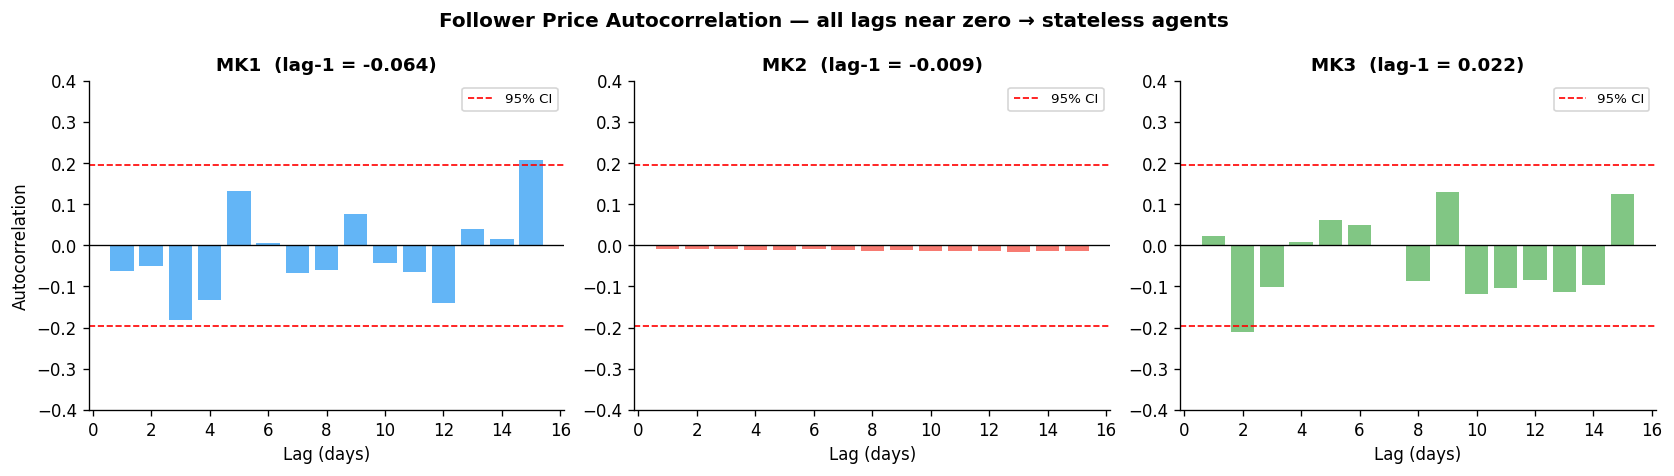

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
max_lags = 15

for ax, (name, df) in zip(axes, followers.items()):
    uf = df["Follower's Price"].values
    n = len(uf)
    lags = range(1, max_lags + 1)
    acf = [np.corrcoef(uf[:-k], uf[k:])[0, 1] for k in lags]
    conf = 1.96 / np.sqrt(n)  # 95% confidence band

    ax.bar(lags, acf, color=colors[name], alpha=0.7)
    ax.axhline(conf,  color='red', ls='--', lw=1, label='95% CI')
    ax.axhline(-conf, color='red', ls='--', lw=1)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylim(-0.4, 0.4)
    ax.set_xlabel("Lag (days)", fontsize=10)
    ax.set_ylabel("Autocorrelation" if ax == axes[0] else "", fontsize=10)
    ax.set_title(f'{name}  (lag-1 = {acf[0]:.3f})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle("Follower Price Autocorrelation — all lags near zero → stateless agents",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 — EWLS fit quality and residuals
How well does the exponentially weighted linear model fit each follower?  
Structured residuals would suggest a better model is needed; random residuals confirm the linear model is appropriate.

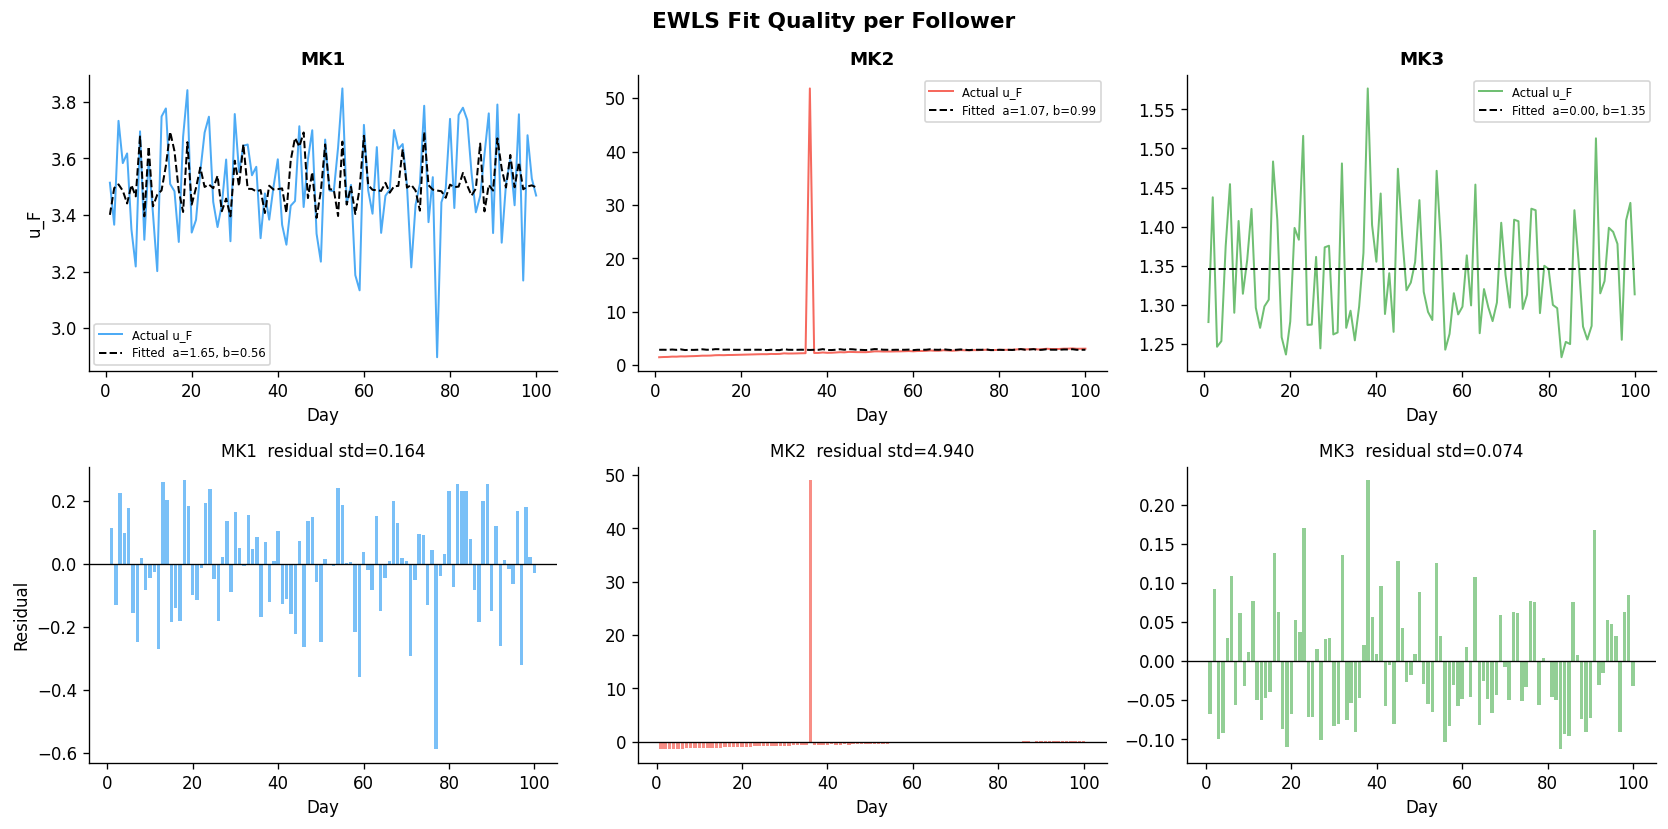

In [6]:
def ewls_fit(ul, uf, decay=0.97):
    """Fit u_F = a*u_L + b using exponential weighting (newest = weight 1)."""
    n = len(ul)
    w = np.array([decay ** (n - 1 - i) for i in range(n)])
    sw   = w.sum()
    swx  = (w * ul).sum()
    swy  = (w * uf).sum()
    swxx = (w * ul * ul).sum()
    swxy = (w * ul * uf).sum()
    denom = sw * swxx - swx ** 2
    if abs(denom) < 1e-10:
        return 0.0, swy / sw
    a = (sw * swxy - swx * swy) / denom
    b = (swy - a * swx) / sw
    return a, b

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for col, (name, df) in enumerate(followers.items()):
    ul = df["Leader's Price"].values
    uf = df["Follower's Price"].values
    days = df['Date'].values

    # Use last 50 days for MK2 (correct regime), last 30 for MK3, all for MK1
    if name == 'MK2':
        ul_fit, uf_fit = ul[50:], uf[50:]
    elif name == 'MK3':
        ul_fit, uf_fit = ul[70:], uf[70:]
    else:
        ul_fit, uf_fit = ul, uf

    a, b = ewls_fit(ul_fit, uf_fit)
    # For MK3 force a=0 (constant model)
    if name == 'MK3':
        n = len(uf_fit)
        w = np.array([0.93 ** (n - 1 - i) for i in range(n)])
        a, b = 0.0, (w * uf_fit).sum() / w.sum()

    fitted = a * ul + b
    residuals = uf - fitted

    # Top: fitted vs actual
    ax_top = axes[0, col]
    ax_top.plot(days, uf, color=colors[name], lw=1.2, label='Actual u_F', alpha=0.8)
    ax_top.plot(days, fitted, 'k--', lw=1.2, label=f'Fitted  a={a:.2f}, b={b:.2f}')
    ax_top.set_title(name, fontsize=11, fontweight='bold')
    ax_top.set_xlabel("Day")
    ax_top.set_ylabel("u_F" if col == 0 else "")
    ax_top.legend(fontsize=7)

    # Bottom: residuals
    ax_bot = axes[1, col]
    ax_bot.bar(days, residuals, color=colors[name], alpha=0.6)
    ax_bot.axhline(0, color='black', lw=0.8)
    ax_bot.set_xlabel("Day")
    ax_bot.set_ylabel("Residual" if col == 0 else "")
    ax_bot.set_title(f'{name}  residual std={residuals.std():.3f}', fontsize=10)

fig.suptitle("EWLS Fit Quality per Follower", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 — Expected profit curves
Given the fitted model for each follower, what is the expected leader profit across all candidate prices?  
The peak of each curve is the Stackelberg optimal price `u_L*`.

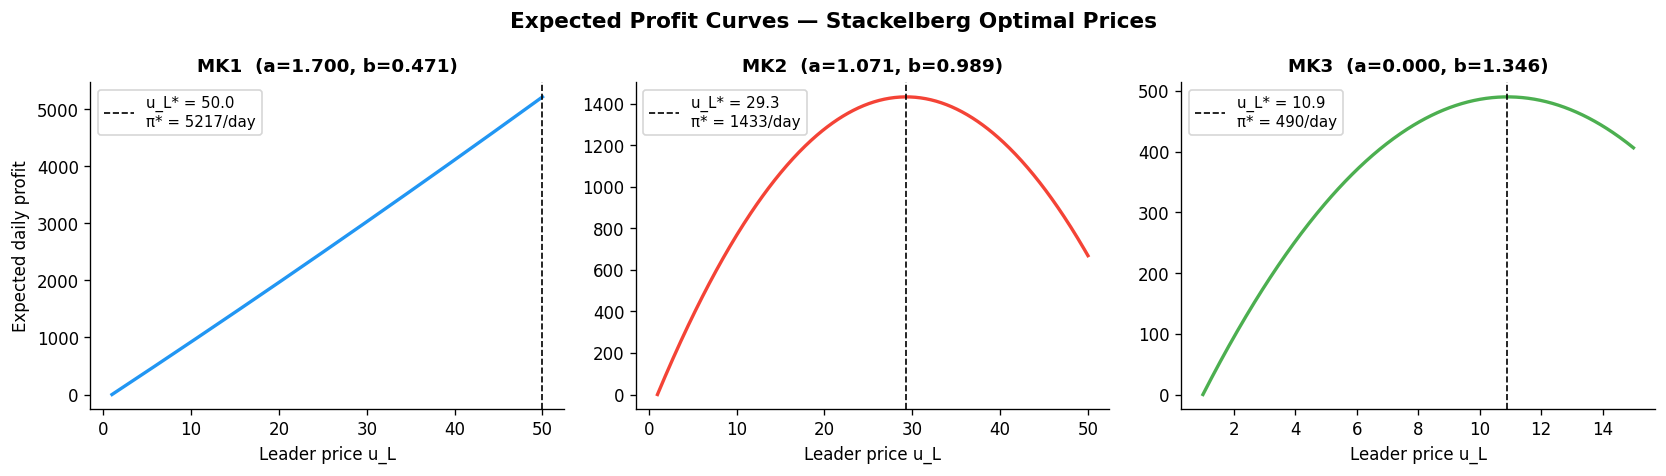

In [7]:
params = {
    'MK1': {'a': None, 'b': None, 'max_price': 50.0, 'decay': 0.95, 'lo': 0,  'hi': 100},
    'MK2': {'a': None, 'b': None, 'max_price': 50.0, 'decay': 0.97, 'lo': 50, 'hi': 100},
    'MK3': {'a': 0.0,  'b': None, 'max_price': 15.0, 'decay': 0.93, 'lo': 70, 'hi': 100},
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, df) in zip(axes, followers.items()):
    ul = df["Leader's Price"].values
    uf = df["Follower's Price"].values
    p  = params[name]
    ul_fit = ul[p['lo']:p['hi']]
    uf_fit = uf[p['lo']:p['hi']]

    if p['a'] is not None:  # MK3: constant model
        n = len(uf_fit)
        w = np.array([p['decay'] ** (n - 1 - i) for i in range(n)])
        a, b = 0.0, (w * uf_fit).sum() / w.sum()
    else:
        a, b = ewls_fit(ul_fit, uf_fit, decay=p['decay'])

    prices = np.linspace(1.0, p['max_price'], 500)
    uf_pred = a * prices + b
    S_L = 100 - 5 * prices + 3 * uf_pred
    profit = (prices - 1) * S_L

    u_opt = prices[np.argmax(profit)]
    pi_opt = profit.max()

    ax.plot(prices, profit, color=colors[name], lw=2)
    ax.axvline(u_opt, color='black', lw=1, ls='--',
               label=f'u_L* = {u_opt:.1f}\nπ* = {pi_opt:.0f}/day')
    ax.set_xlabel("Leader price u_L", fontsize=10)
    ax.set_ylabel("Expected daily profit" if ax == axes[0] else "", fontsize=10)
    ax.set_title(f'{name}  (a={a:.3f}, b={b:.3f})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle("Expected Profit Curves — Stackelberg Optimal Prices",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7 — Strategy summary table

In [8]:
summary = pd.DataFrame([
    {
        'Leader':        'LeaderMK1',
        'Follower':      'MK1',
        'Key finding':   'Linear, slope drifts +58% over 100 days',
        'History used':  'All 100 days',
        'Model':         'Linear (a, b)',
        'decay':         0.95,
        'max_price':     50,
        'Overrides':     '__init__ only',
    },
    {
        'Leader':        'LeaderMK2',
        'Follower':      'MK2',
        'Key finding':   'Regime flip at day 50 (slope sign flips)',
        'History used':  'Last 50 days only',
        'Model':         'Linear (a, b)',
        'decay':         0.97,
        'max_price':     50,
        'Overrides':     '__init__ + start_simulation',
    },
    {
        'Leader':        'LeaderMK3',
        'Follower':      'MK3',
        'Key finding':   'Near-constant follower, R²=0.038 (borderline)',
        'History used':  'Last 30 days only',
        'Model':         'Constant (a=0, b=mean u_F)',
        'decay':         0.93,
        'max_price':     15,
        'Overrides':     '__init__ + start_simulation + _fit_ewls',
    },
])

display(summary.set_index('Leader'))

,Follower,Key finding,History used,Model,decay,max_price,Overrides
Leader,,,,,,,
LeaderMK1,MK1,"Linear, slope drifts +58% over 100 days",All 100 days,"Linear (a, b)",0.95,50,__init__ only
LeaderMK2,MK2,Regime flip at day 50 (slope sign flips),Last 50 days only,"Linear (a, b)",0.97,50,__init__ + start_simulation
LeaderMK3,MK3,"Near-constant follower, R²=0.038 (borderline)",Last 30 days only,"Constant (a=0, b=mean u_F)",0.93,15,__init__ + start_simulation + _fit_ewls
